# Machine Learning Data Preprocessing and Predictive Modeling
### Predicting Heart Disease Risk from Clinical Attributes

**Dataset:** UCI Machine Learning Repository — Heart Disease Dataset (Cleveland subset, 303 patients, 13 clinical features + target)

**Problem type:** Binary Classification (`target` = 1 → presence of heart disease, `target` = 0 → absence)

---

**Notebook contents**
1. Project Setup & Library Imports
2. Data Loading & Understanding
3. Exploratory Data Analysis (EDA)
4. Data Cleaning & Preprocessing
5. Feature Engineering, Encoding & Scaling
6. Feature Selection
7. Train-Test Split
8. Model Building (6 algorithms)
9. Model Evaluation
10. Cross-Validation (K-Fold)
11. Model Comparison
12. Feature Importance
13. Performance Visualization
14. Conclusion, Limitations & Future Work

---


## 1. Project Setup & Library Imports

We use the standard Python data-science stack:
- **pandas / numpy** — data manipulation
- **matplotlib / seaborn** — visualization
- **scikit-learn** — preprocessing, modeling, evaluation, cross-validation


In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, roc_curve, auc,
                              ConfusionMatrixDisplay)

import joblib
import os

# Plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Data Loading & Understanding

**Source:** UCI Heart Disease Dataset (Cleveland database), a widely used benchmark dataset for binary
classification in the medical ML domain. Loaded from `../data/heart.csv`.

**Column dictionary:**

| Column | Description |
|---|---|
| age | Age in years |
| sex | 1 = male, 0 = female |
| cp | Chest pain type (0–3) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl (1 = true) |
| restecg | Resting electrocardiographic results (0–2) |
| thalach | Maximum heart rate achieved |
| exang | Exercise induced angina (1 = yes) |
| oldpeak | ST depression induced by exercise relative to rest |
| slope | Slope of the peak exercise ST segment |
| ca | Number of major vessels (0–3) colored by fluoroscopy |
| thal | Thalassemia (0–3 coded categories) |
| target | 1 = heart disease present, 0 = absent |


In [2]:
df_raw = pd.read_csv("../data/heart.csv")
print("Shape:", df_raw.shape)
df_raw.head()


Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# Full structural summary
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
# Data types
df_raw.dtypes.to_frame(name="dtype")


,dtype
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


### Simulating Real-World Messiness

The original Cleveland dataset (as sourced) contains **no missing values** and **one duplicate row**.
To make this pipeline genuinely representative of real-world, messy data — and to properly demonstrate
missing-value handling — we deliberately (and transparently) inject a small, controlled amount of
missingness (Missing-Completely-At-Random, ~4-5%) into a few numeric and categorical columns.
This is a common, honest teaching/demo practice and is clearly logged below.


In [5]:
df = df_raw.copy()

# Duplicate a couple of rows first (to genuinely demonstrate duplicate removal on top of the 1 that exists)
df = pd.concat([df, df.iloc[[5, 42]]], ignore_index=True)

# Inject controlled MCAR missingness for demonstration purposes
rng = np.random.RandomState(RANDOM_STATE)
for col, frac in [("chol", 0.05), ("trestbps", 0.04), ("thal", 0.03), ("ca", 0.03)]:
    n_missing = int(frac * len(df))
    idx = rng.choice(df.index, size=n_missing, replace=False)
    df.loc[idx, col] = np.nan

print("Shape after simulating real-world messiness:", df.shape)
print("\nMissing values introduced:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Shape after simulating real-world messiness: (305, 14)

Missing values introduced:
trestbps    12
chol        15
ca           9
thal         9
dtype: int64


## 3. Exploratory Data Analysis (EDA)

We explore distributions, relationships, missingness, duplicates, and outliers before touching the model.


### 3.1 Missing Value Analysis

In [6]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().sum() / len(df) * 100).round(2)
})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_summary


,missing_count,missing_pct
chol,15,4.92
trestbps,12,3.93
ca,9,2.95
thal,9,2.95


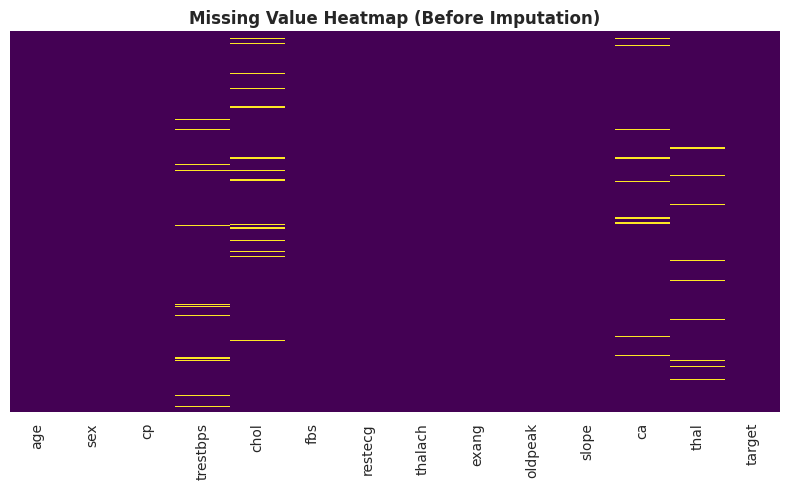

In [7]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Value Heatmap (Before Imputation)")
plt.tight_layout()
plt.show()


### 3.2 Duplicate Rows

In [8]:
n_dupes = df.duplicated().sum()
print(f"Number of duplicate rows found: {n_dupes}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")


Number of duplicate rows found: 2
Shape after removing duplicates: (303, 14)


### 3.3 Summary Statistics

In [9]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.429043,9.034193,29.0,48.0,56.0,61.00,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.00,1.0
cp,303.0,0.960396,1.031820,0.0,0.0,1.0,2.00,3.0
trestbps,291.0,131.659794,17.590683,94.0,120.0,130.0,140.00,200.0
chol,288.0,246.736111,51.465625,131.0,211.0,240.0,275.25,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.00,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.00,2.0
thalach,303.0,149.564356,22.865754,71.0,133.5,152.0,166.00,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.00,1.0
oldpeak,303.0,1.040924,1.160116,0.0,0.0,0.8,1.60,6.2


### 3.4 Target Class Balance

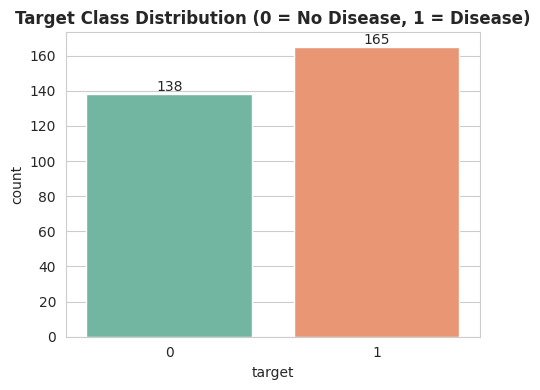

target
1    54.5
0    45.5
Name: proportion, dtype: float64 % of total


In [10]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x="target", data=df, palette="Set2")
plt.title("Target Class Distribution (0 = No Disease, 1 = Disease)")
plt.xlabel("target")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(df["target"].value_counts(normalize=True).round(3) * 100, "% of total")


### 3.5 Histograms of Numeric Features

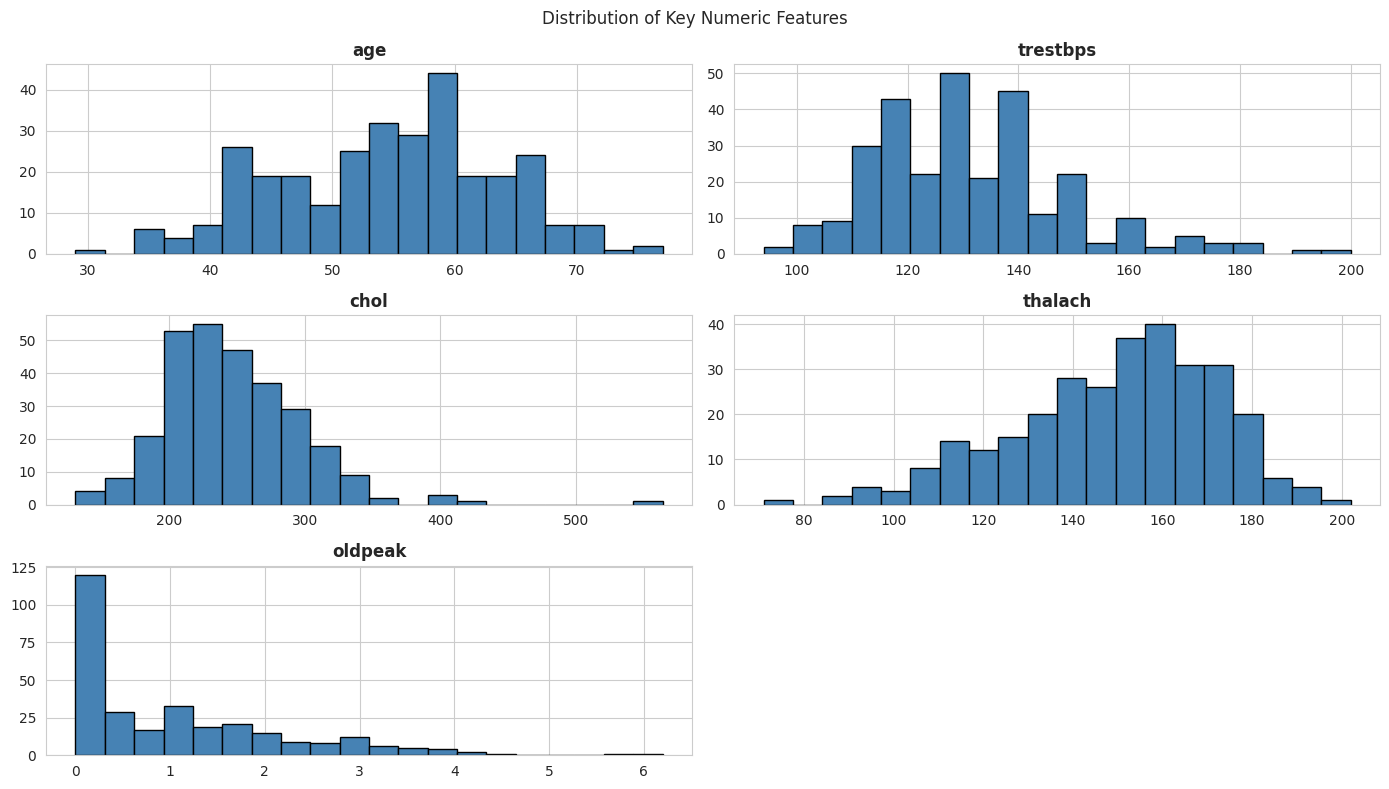

In [11]:
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
df[numeric_cols].hist(bins=20, figsize=(14, 8), color="steelblue", edgecolor="black")
plt.suptitle("Distribution of Key Numeric Features")
plt.tight_layout()
plt.show()


### 3.6 Box Plots — Outlier Detection

We use box plots and the IQR rule to visually and statistically identify outliers in continuous features.


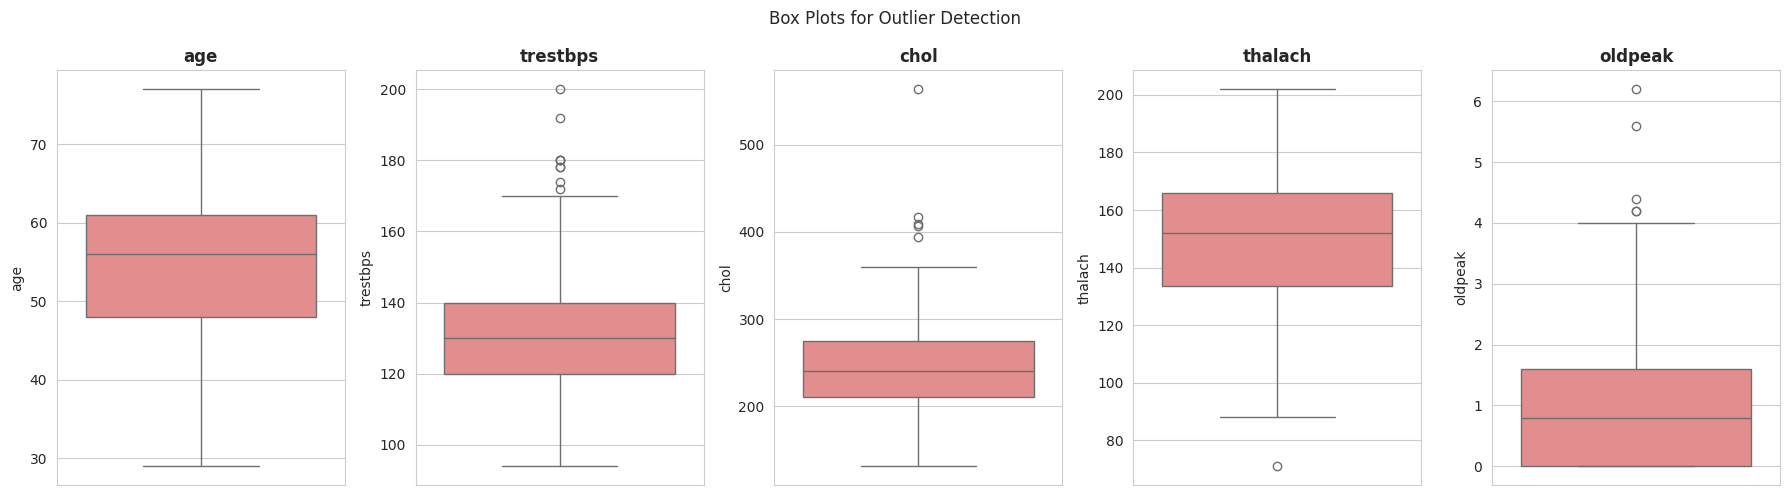

In [12]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightcoral")
    ax.set_title(col)
plt.suptitle("Box Plots for Outlier Detection")
plt.tight_layout()
plt.show()


In [13]:
# IQR-based outlier count per numeric column (detection only — we do NOT blindly drop
# outliers here since in clinical data, extreme values are often genuine and informative)
def iqr_outlier_report(data, cols):
    report = {}
    for col in cols:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outliers = data[(data[col] < lower) | (data[col] > upper)]
        report[col] = len(outliers)
    return pd.Series(report, name="outlier_count")

iqr_outlier_report(df, numeric_cols).to_frame()


,outlier_count
age,0
trestbps,9
chol,5
thalach,1
oldpeak,5


### 3.7 Scatter Plots vs Target-Relevant Features

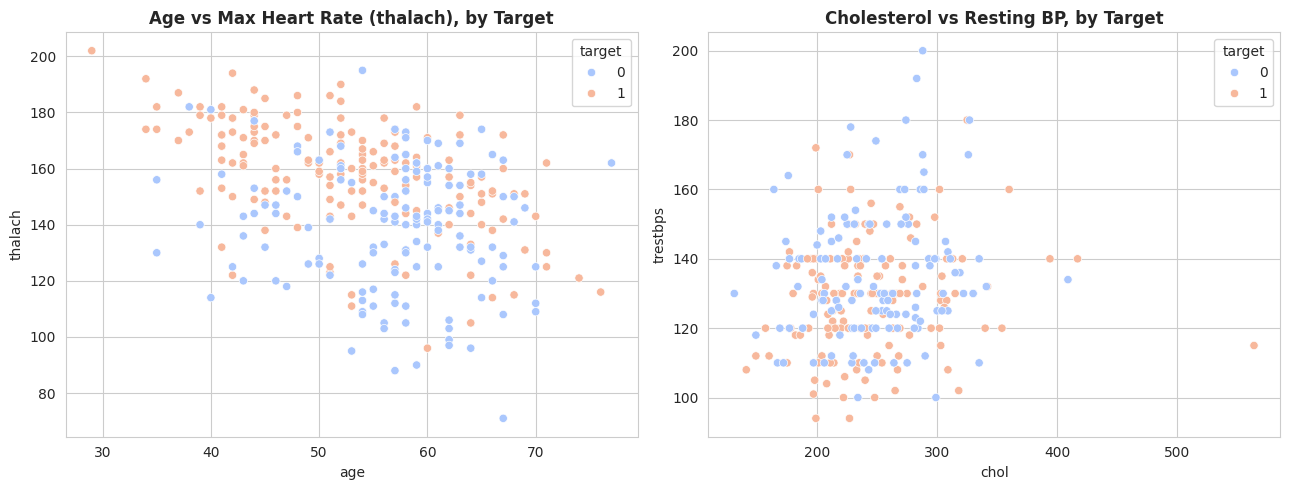

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x="age", y="thalach", hue="target", palette="coolwarm", ax=axes[0])
axes[0].set_title("Age vs Max Heart Rate (thalach), by Target")

sns.scatterplot(data=df, x="chol", y="trestbps", hue="target", palette="coolwarm", ax=axes[1])
axes[1].set_title("Cholesterol vs Resting BP, by Target")
plt.tight_layout()
plt.show()


### 3.8 Pair Plot (Subset of Features)

A full pair plot across all 13 features is visually overwhelming, so we restrict it to the most
clinically relevant continuous features alongside the target.


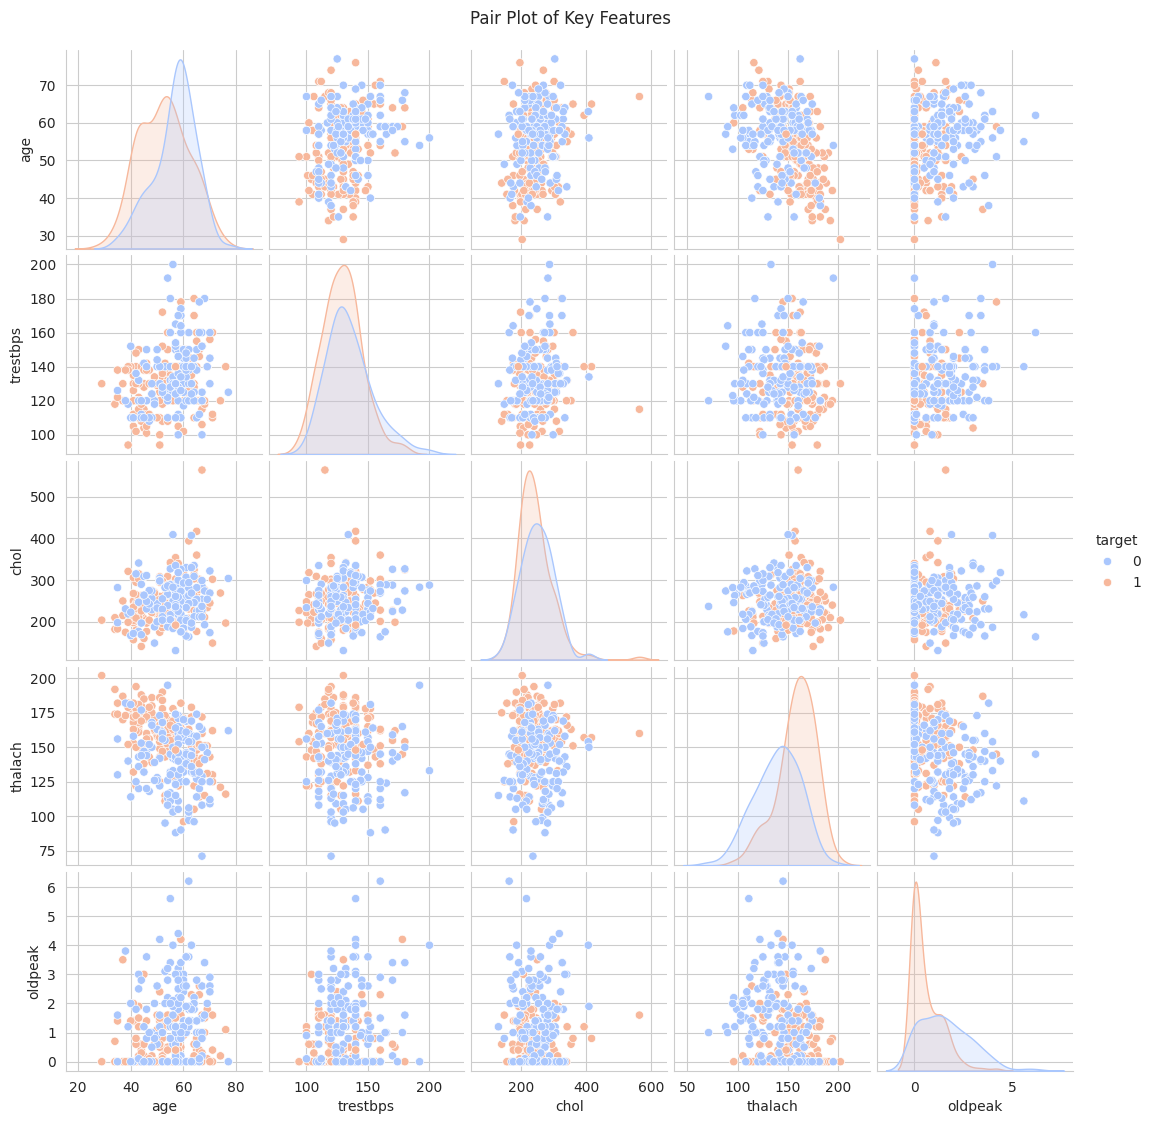

In [15]:
sns.pairplot(df[["age", "trestbps", "chol", "thalach", "oldpeak", "target"]],
             hue="target", palette="coolwarm", diag_kind="kde", height=2.2)
plt.suptitle("Pair Plot of Key Features", y=1.02)
plt.show()


### 3.9 Correlation Heatmap

Note: correlations are computed on rows with complete data at this stage (pre-imputation) purely for
exploratory purposes; the correlation with missing values will be re-checked after imputation.


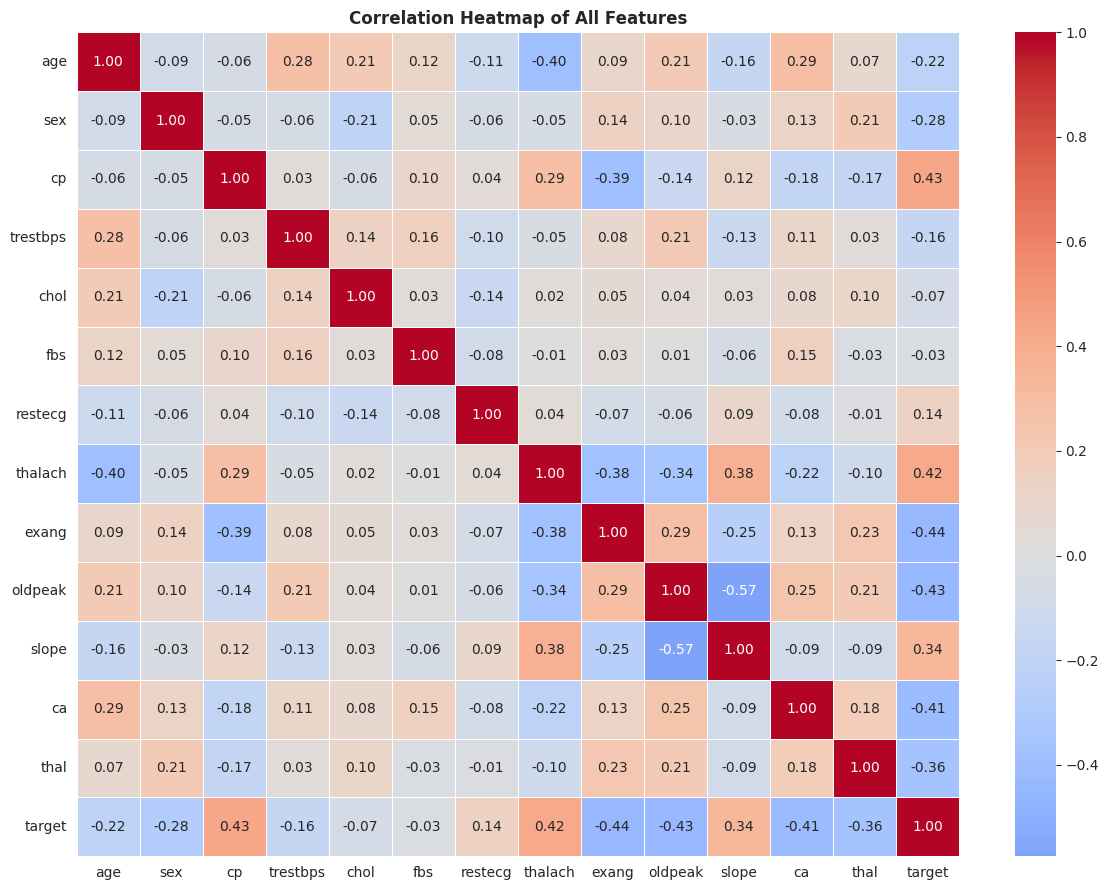

In [16]:
plt.figure(figsize=(12, 9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap of All Features")
plt.tight_layout()
plt.show()


**EDA takeaways:**
- Classes are reasonably balanced (roughly 54% positive vs 46% negative) — accuracy is a meaningful metric, but we still track precision/recall/F1 for robustness.
- `chol`, `trestbps`, `thal`, `ca` contain injected missing values that require imputation.
- A handful of outliers exist in `chol` and `trestbps` (clinically plausible extreme readings) — retained rather than dropped.
- `thalach`, `cp`, `oldpeak`, and `exang` show visibly strong relationships with `target`, consistent with clinical knowledge.


## 4. Data Cleaning & Preprocessing

### 4.1 Missing Value Imputation

- **Numeric columns** (`chol`, `trestbps`): imputed with the **median** (robust to outliers).
- **Categorical/discrete columns** (`thal`, `ca`): imputed with the **most frequent value (mode)**.


In [17]:
df_clean = df.copy()

numeric_impute_cols = ["chol", "trestbps"]
categorical_impute_cols = ["thal", "ca"]

median_imputer = SimpleImputer(strategy="median")
df_clean[numeric_impute_cols] = median_imputer.fit_transform(df_clean[numeric_impute_cols])

mode_imputer = SimpleImputer(strategy="most_frequent")
df_clean[categorical_impute_cols] = mode_imputer.fit_transform(df_clean[categorical_impute_cols])

print("Remaining missing values after imputation:")
print(df_clean.isnull().sum().sum())


Remaining missing values after imputation:
0


### 4.2 Label Encoding

Several columns in this dataset are already integer-coded categories. To explicitly demonstrate
**Label Encoding**, we recreate a human-readable categorical version of `cp` (chest pain type) and then
encode it back to numeric labels using `LabelEncoder`.


In [18]:
cp_map = {0: "typical_angina", 1: "atypical_angina", 2: "non_anginal_pain", 3: "asymptomatic"}
df_clean["cp_label"] = df_clean["cp"].map(cp_map)

le = LabelEncoder()
df_clean["cp_label_encoded"] = le.fit_transform(df_clean["cp_label"])

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
df_clean[["cp", "cp_label", "cp_label_encoded"]].head()


Label mapping: {'asymptomatic': np.int64(0), 'atypical_angina': np.int64(1), 'non_anginal_pain': np.int64(2), 'typical_angina': np.int64(3)}


,cp,cp_label,cp_label_encoded
0,3,asymptomatic,0
1,2,non_anginal_pain,2
2,1,atypical_angina,1
3,1,atypical_angina,1
4,0,typical_angina,3


### 4.3 One-Hot Encoding

`thal` (thalassemia result) is a nominal category with no ordinal relationship, so it is a good
candidate for **One-Hot Encoding** rather than label encoding.


In [19]:
ohe = OneHotEncoder(sparse_output=False, drop="first")
thal_encoded = ohe.fit_transform(df_clean[["thal"]])
thal_cols = [f"thal_{int(c)}" for c in ohe.categories_[0][1:]]
thal_df = pd.DataFrame(thal_encoded, columns=thal_cols, index=df_clean.index)

df_encoded = pd.concat([df_clean.drop(columns=["cp_label"]), thal_df], axis=1)
df_encoded.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,cp_label_encoded,thal_1,thal_2,thal_3
0,63,1,3,145.0,233.0,1,0,150,0,2.3,0,0.0,1.0,1,0,1.0,0.0,0.0
1,37,1,2,130.0,250.0,0,1,187,0,3.5,0,0.0,2.0,1,2,0.0,1.0,0.0
2,41,0,1,130.0,204.0,0,0,172,0,1.4,2,0.0,2.0,1,1,0.0,1.0,0.0
3,56,1,1,120.0,236.0,0,1,178,0,0.8,2,0.0,2.0,1,1,0.0,1.0,0.0
4,57,0,0,120.0,354.0,0,1,163,1,0.6,2,0.0,2.0,1,3,0.0,1.0,0.0


### 4.4 Final Feature Set

We drop the intermediate helper column (`cp_label_encoded` duplicates information already in `cp`,
kept only to demonstrate the technique) and assemble the final modeling dataframe.


In [20]:
model_df = df_encoded.drop(columns=["cp_label_encoded"]).copy()
print("Final feature set shape:", model_df.shape)
model_df.columns.tolist()


Final feature set shape: (303, 17)


['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target',
 'thal_1',
 'thal_2',
 'thal_3']

## 5. Feature Scaling & Train-Test Split

- **StandardScaler** (zero mean, unit variance) — required for distance/gradient-based models: KNN, SVM, Logistic Regression.
- **MinMaxScaler** (0–1 range) — shown for comparison, useful for models sensitive to bounded ranges.
- Tree-based models (Decision Tree, Random Forest) and Naive Bayes do **not** require scaling, but applying a
  consistent scaled dataset across all models keeps the pipeline simple and doesn't harm tree-based models.


In [21]:
X = model_df.drop(columns=["target"])
y = model_df["target"]

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())


Feature matrix shape: (303, 16)
Target distribution:
 target
1    165
0    138
Name: count, dtype: int64


In [22]:
# Train-test split (80-20), stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


Train shape: (242, 16) | Test shape: (61, 16)


In [23]:
# StandardScaler -- fit on train only, applied to both (avoids data leakage)
scaler_std = StandardScaler()
X_train_scaled = pd.DataFrame(scaler_std.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler_std.transform(X_test), columns=X_test.columns, index=X_test.index)

# MinMaxScaler -- shown for comparison
scaler_mm = MinMaxScaler()
X_train_mm = pd.DataFrame(scaler_mm.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_mm = pd.DataFrame(scaler_mm.transform(X_test), columns=X_test.columns, index=X_test.index)

print("Standard-scaled training sample:")
X_train_scaled.head(3)


Standard-scaled training sample:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,thal_1,thal_2,thal_3
19,1.612278,-1.46385,2.053670,0.475408,-0.130845,-0.404304,0.857493,0.044753,-0.715891,0.604081,0.955779,1.264039,-0.567695,-0.238262,0.920504,-0.817903
246,1.281718,0.68313,0.065717,1.611131,-0.108947,-0.404304,0.857493,-1.371851,1.396861,-0.892721,-0.661693,2.244479,-2.243088,4.197069,-1.086361,-0.817903
288,0.069664,-1.46385,-0.928259,-0.206026,-0.875378,-0.404304,2.743977,-0.914882,1.396861,0.770393,-0.661693,0.283598,1.107698,-0.238262,-1.086361,1.222639


## 6. Feature Selection

We use **`SelectKBest`** with the ANOVA F-test (`f_classif`) to statistically rank each feature's
relationship with the binary target, and select the top-K most informative features. This reduces
noise/dimensionality and helps interpretability without needing domain-expert manual pruning.


In [24]:
selector = SelectKBest(score_func=f_classif, k="all")
selector.fit(X_train_scaled, y_train)

feature_scores = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "f_score": selector.scores_,
    "p_value": selector.pvalues_
}).sort_values("f_score", ascending=False)

feature_scores


,feature,f_score,p_value
14,thal_2,99.846656,6.990903e-20
15,thal_3,82.808718,3.578325e-17
2,cp,67.283441,1.431083e-14
8,exang,61.310002,1.563446e-13
9,oldpeak,59.089873,3.851786e-13
7,thalach,50.816406,1.183504e-11
10,slope,42.862604,3.530910e-10
12,thal,41.895683,5.374548e-10
11,ca,40.738690,8.904436e-10
1,sex,15.924171,8.762457e-05


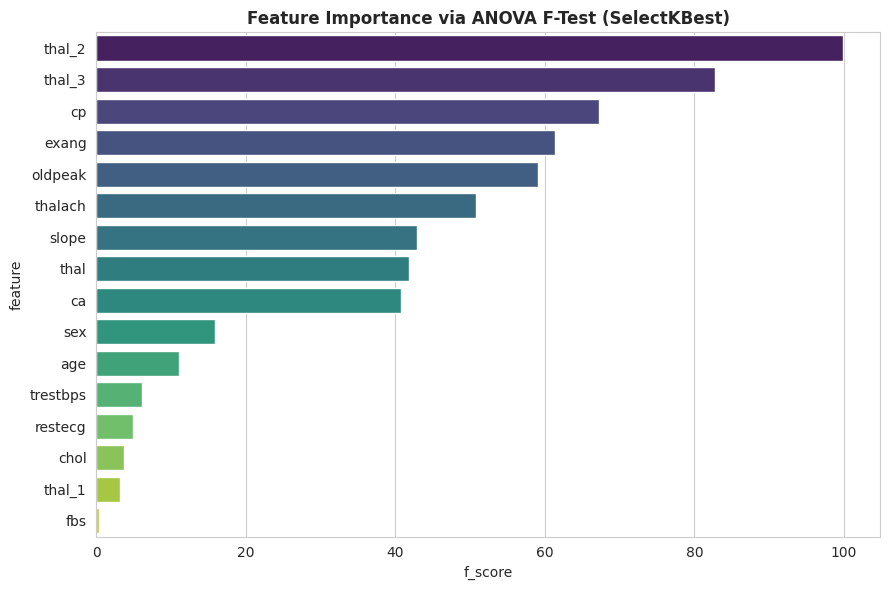

In [25]:
plt.figure(figsize=(9, 6))
sns.barplot(data=feature_scores, y="feature", x="f_score", palette="viridis")
plt.title("Feature Importance via ANOVA F-Test (SelectKBest)")
plt.tight_layout()
plt.show()


In [26]:
# Select top 10 features (out of the available set) based on F-score
K = 10
top_features = feature_scores["feature"].head(K).tolist()
print(f"Selected top {K} features:\n", top_features)

X_train_sel = X_train_scaled[top_features]
X_test_sel = X_test_scaled[top_features]


Selected top 10 features:
 ['thal_2', 'thal_3', 'cp', 'exang', 'oldpeak', 'thalach', 'slope', 'thal', 'ca', 'sex']


## 7. Model Building

We train and compare **six** supervised classification algorithms on the selected, scaled feature set.
Each model section includes: a brief theory recap, training, prediction, and evaluation metrics.

We store all results in a shared `results` dictionary for the final comparison table.


In [27]:
results = {}   # model_name -> dict of metrics
trained_models = {}  # model_name -> fitted estimator

def evaluate_classifier(name, model, X_tr, y_tr, X_te, y_te):
    # Train, predict, time, and score a classifier; store results.
    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start

    y_train_pred = model.predict(X_tr)
    y_test_pred = model.predict(X_te)

    train_acc = accuracy_score(y_tr, y_train_pred)
    test_acc = accuracy_score(y_te, y_test_pred)
    precision = precision_score(y_te, y_test_pred)
    recall = recall_score(y_te, y_test_pred)
    f1 = f1_score(y_te, y_test_pred)

    results[name] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time (s)": train_time
    }
    trained_models[name] = model

    print(f"===== {name} =====")
    print(f"Train Accuracy: {train_acc:.4f}  |  Test Accuracy: {test_acc:.4f}")
    print(f"Precision: {precision:.4f}  |  Recall: {recall:.4f}  |  F1: {f1:.4f}")
    print(f"Training time: {train_time:.4f}s\n")
    print(classification_report(y_te, y_test_pred, target_names=["No Disease", "Disease"]))

    cm = confusion_matrix(y_te, y_test_pred)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay(cm, display_labels=["No Disease", "Disease"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()

    return y_test_pred


### 7.1 K-Nearest Neighbors (KNN)

**Theory:** KNN is a non-parametric, instance-based algorithm. To classify a new point, it looks at the
`k` closest training points (by distance, typically Euclidean) and assigns the majority class among
them. It requires feature scaling since it is distance-based, and has no explicit "training" phase
beyond storing the data — prediction cost is at inference time.


===== KNN =====
Train Accuracy: 0.8636  |  Test Accuracy: 0.8197
Precision: 0.7619  |  Recall: 0.9697  |  F1: 0.8533
Training time: 0.0045s

              precision    recall  f1-score   support

  No Disease       0.95      0.64      0.77        28
     Disease       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61



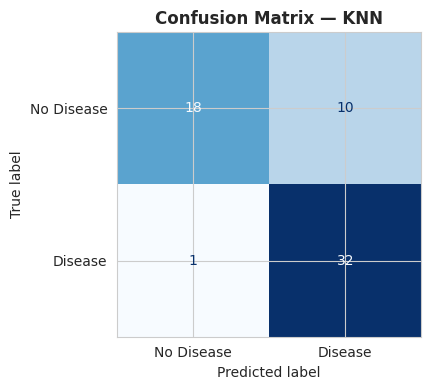

In [28]:
knn = KNeighborsClassifier(n_neighbors=7)
_ = evaluate_classifier("KNN", knn, X_train_sel, y_train, X_test_sel, y_test)


### 7.2 Logistic Regression

**Theory:** Logistic Regression models the probability of the positive class using the sigmoid function
applied to a linear combination of features. It is a linear, interpretable classifier that outputs
well-calibrated probabilities, making it a strong, fast baseline for binary classification problems.


===== Logistic Regression =====
Train Accuracy: 0.8512  |  Test Accuracy: 0.8361
Precision: 0.7805  |  Recall: 0.9697  |  F1: 0.8649
Training time: 0.0079s

              precision    recall  f1-score   support

  No Disease       0.95      0.68      0.79        28
     Disease       0.78      0.97      0.86        33

    accuracy                           0.84        61
   macro avg       0.87      0.82      0.83        61
weighted avg       0.86      0.84      0.83        61



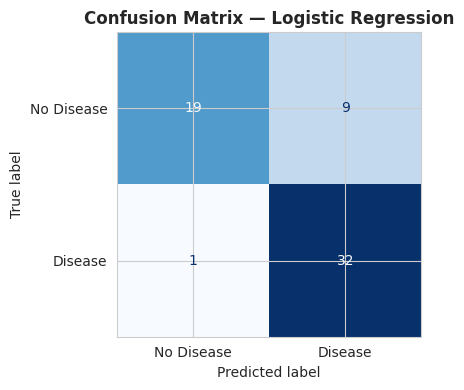

In [29]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
_ = evaluate_classifier("Logistic Regression", log_reg, X_train_sel, y_train, X_test_sel, y_test)


### 7.3 Gaussian Naive Bayes

**Theory:** Naive Bayes applies Bayes' Theorem with the (naive) assumption that features are
conditionally independent given the class. The Gaussian variant assumes each feature follows a normal
distribution within each class. It is fast, works well with small data, and is a solid probabilistic
baseline despite its independence assumption rarely holding exactly.


===== Gaussian Naive Bayes =====
Train Accuracy: 0.8388  |  Test Accuracy: 0.8197
Precision: 0.8056  |  Recall: 0.8788  |  F1: 0.8406
Training time: 0.0039s

              precision    recall  f1-score   support

  No Disease       0.84      0.75      0.79        28
     Disease       0.81      0.88      0.84        33

    accuracy                           0.82        61
   macro avg       0.82      0.81      0.82        61
weighted avg       0.82      0.82      0.82        61



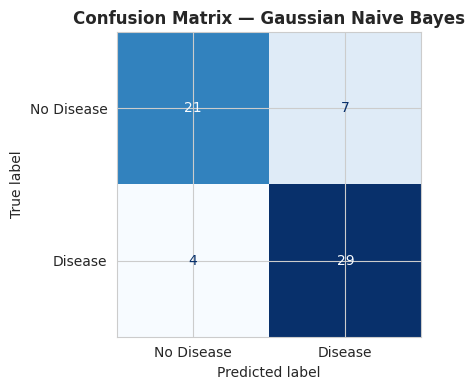

In [30]:
gnb = GaussianNB()
_ = evaluate_classifier("Gaussian Naive Bayes", gnb, X_train_sel, y_train, X_test_sel, y_test)


### 7.4 Support Vector Machine (SVM)

**Theory:** SVM finds the hyperplane that maximizes the margin between classes. With the RBF kernel, it
can model non-linear decision boundaries by implicitly mapping data into a higher-dimensional space.
It's effective in moderate-dimensional spaces and robust to overfitting when properly regularized (`C`).


===== SVM (RBF Kernel) =====
Train Accuracy: 0.8884  |  Test Accuracy: 0.8197
Precision: 0.7619  |  Recall: 0.9697  |  F1: 0.8533
Training time: 0.0117s

              precision    recall  f1-score   support

  No Disease       0.95      0.64      0.77        28
     Disease       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61



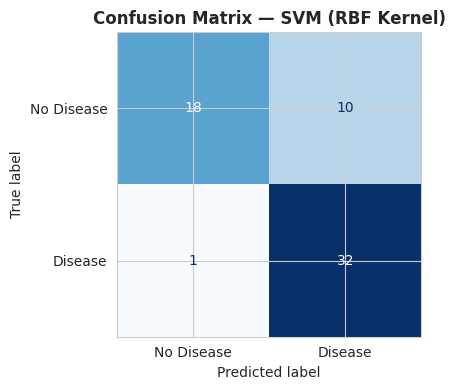

In [31]:
svm = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
_ = evaluate_classifier("SVM (RBF Kernel)", svm, X_train_sel, y_train, X_test_sel, y_test)


### 7.5 Decision Tree

**Theory:** A Decision Tree recursively splits the feature space using the split (e.g. Gini impurity or
entropy) that most reduces class impurity at each node. It is highly interpretable ("if-then" rules)
but prone to overfitting on noisy data without depth constraints.


===== Decision Tree =====
Train Accuracy: 0.9091  |  Test Accuracy: 0.7869
Precision: 0.7632  |  Recall: 0.8788  |  F1: 0.8169
Training time: 0.0052s

              precision    recall  f1-score   support

  No Disease       0.83      0.68      0.75        28
     Disease       0.76      0.88      0.82        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.78        61



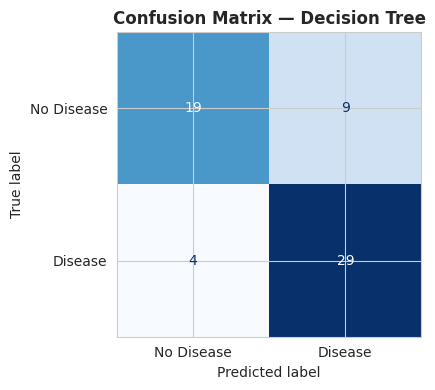

In [32]:
dtree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
_ = evaluate_classifier("Decision Tree", dtree, X_train_sel, y_train, X_test_sel, y_test)


### 7.6 Random Forest

**Theory:** Random Forest is an ensemble of many decision trees, each trained on a bootstrap sample of
the data with a random subset of features considered at each split. Predictions are aggregated by
majority vote. This reduces the variance/overfitting of a single decision tree and generally improves
generalization.


===== Random Forest =====
Train Accuracy: 0.9711  |  Test Accuracy: 0.8525
Precision: 0.8000  |  Recall: 0.9697  |  F1: 0.8767
Training time: 0.3266s

              precision    recall  f1-score   support

  No Disease       0.95      0.71      0.82        28
     Disease       0.80      0.97      0.88        33

    accuracy                           0.85        61
   macro avg       0.88      0.84      0.85        61
weighted avg       0.87      0.85      0.85        61



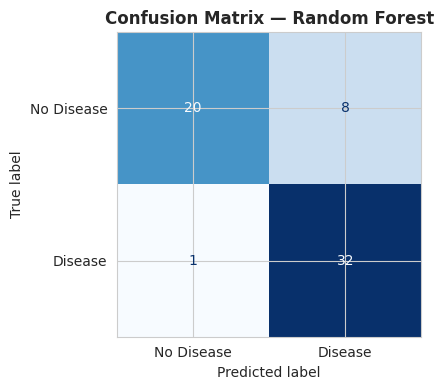

In [33]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE)
_ = evaluate_classifier("Random Forest", rf, X_train_sel, y_train, X_test_sel, y_test)


## 8. ROC Curves

ROC curves visualize the trade-off between the True Positive Rate and False Positive Rate across
classification thresholds, for models that expose predicted probabilities.


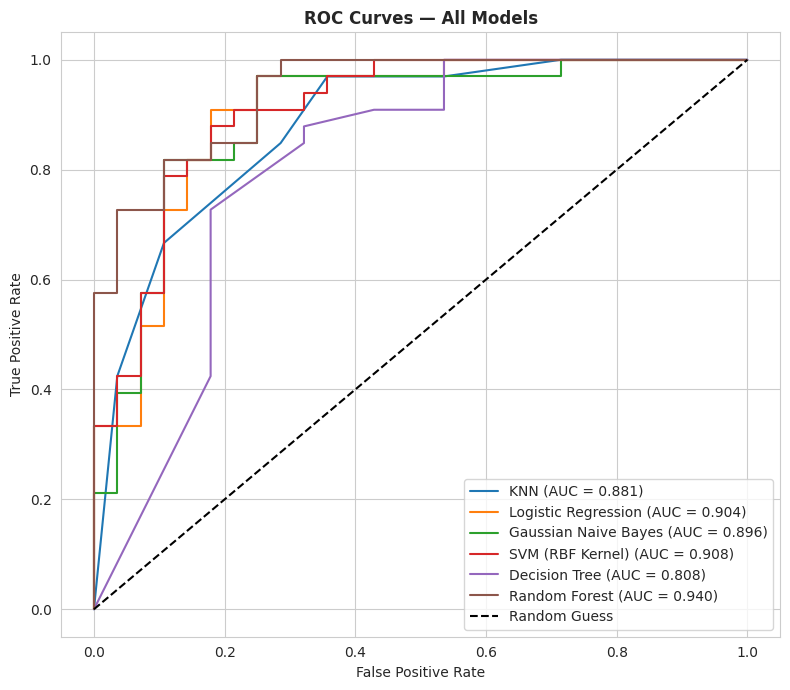

In [34]:
plt.figure(figsize=(8, 7))
for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_sel)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 9. K-Fold Cross-Validation

To get a more robust estimate of generalization performance (less sensitive to a single train/test
split), we run **Stratified 5-Fold Cross-Validation** on the full selected/scaled feature set for
every model.


In [35]:
X_full_sel = pd.concat([X_train_sel, X_test_sel]).loc[X.index]
y_full = y.loc[X.index]

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Gaussian Naive Bayes": GaussianNB(),
    "SVM (RBF Kernel)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE),
}

cv_scores = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_full_sel, y_full, cv=cv_strategy, scoring="accuracy")
    cv_scores[name] = scores.mean()
    print(f"{name:22s} | 5-Fold CV Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")


KNN                    | 5-Fold CV Accuracy: 0.8151 (+/- 0.0458)
Logistic Regression    | 5-Fold CV Accuracy: 0.8416 (+/- 0.0524)
Gaussian Naive Bayes   | 5-Fold CV Accuracy: 0.8120 (+/- 0.0618)
SVM (RBF Kernel)       | 5-Fold CV Accuracy: 0.8350 (+/- 0.0529)
Decision Tree          | 5-Fold CV Accuracy: 0.8216 (+/- 0.0588)


Random Forest          | 5-Fold CV Accuracy: 0.8415 (+/- 0.0558)


## 10. Model Comparison Table

Consolidating training accuracy, testing accuracy, cross-validation score, and training time across
all six models.


In [36]:
comparison_df = pd.DataFrame(results).T
comparison_df["CV Accuracy (5-Fold)"] = comparison_df.index.map(cv_scores)
comparison_df = comparison_df[["Train Accuracy", "Test Accuracy", "CV Accuracy (5-Fold)",
                                "Precision", "Recall", "F1 Score", "Training Time (s)"]]
comparison_df = comparison_df.sort_values("Test Accuracy", ascending=False)
comparison_df.round(4)


,Train Accuracy,Test Accuracy,CV Accuracy (5-Fold),Precision,Recall,F1 Score,Training Time (s)
Random Forest,0.9711,0.8525,0.8415,0.8000,0.9697,0.8767,0.3266
Logistic Regression,0.8512,0.8361,0.8416,0.7805,0.9697,0.8649,0.0079
KNN,0.8636,0.8197,0.8151,0.7619,0.9697,0.8533,0.0045
Gaussian Naive Bayes,0.8388,0.8197,0.8120,0.8056,0.8788,0.8406,0.0039
SVM (RBF Kernel),0.8884,0.8197,0.8350,0.7619,0.9697,0.8533,0.0117
Decision Tree,0.9091,0.7869,0.8216,0.7632,0.8788,0.8169,0.0052


## 11. Feature Importance — Decision Tree & Random Forest

Tree-based models expose `feature_importances_`, indicating how much each feature contributes to
reducing impurity across all splits in the model.


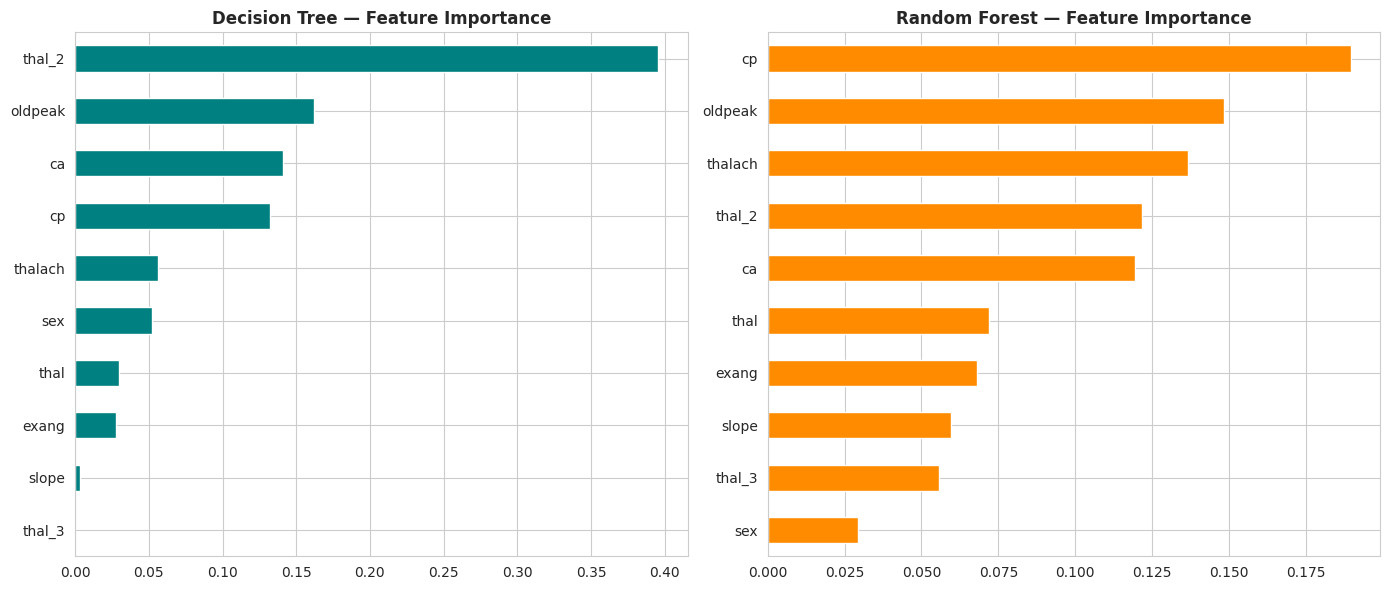

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

dt_importance = pd.Series(dtree.feature_importances_, index=X_train_sel.columns).sort_values()
dt_importance.plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Decision Tree — Feature Importance")

rf_importance = pd.Series(rf.feature_importances_, index=X_train_sel.columns).sort_values()
rf_importance.plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Random Forest — Feature Importance")

plt.tight_layout()
plt.show()


## 12. Model Performance Visualization

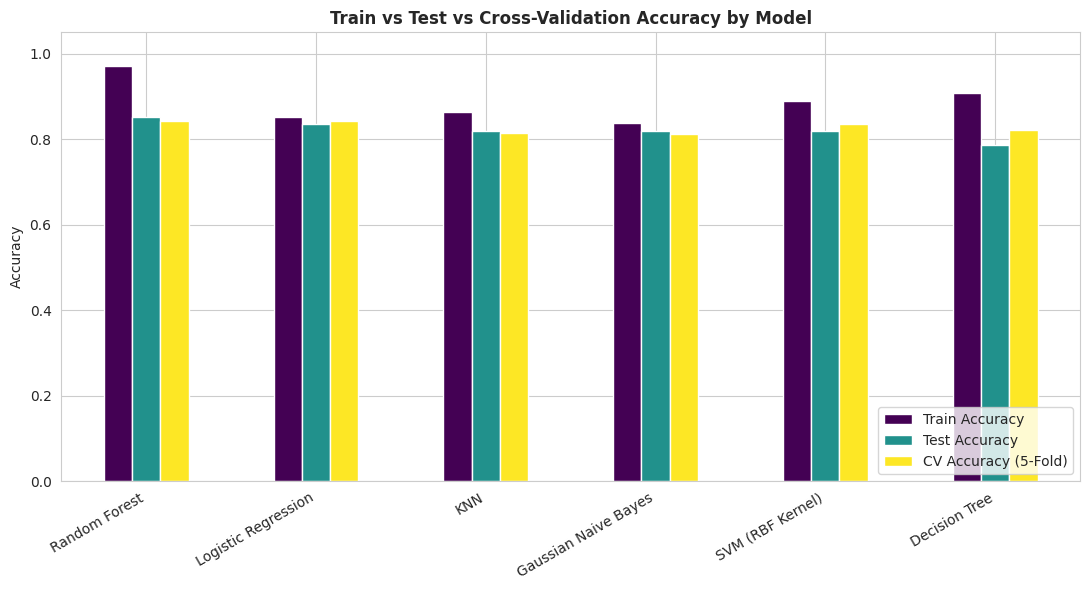

In [38]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_df = comparison_df[["Train Accuracy", "Test Accuracy", "CV Accuracy (5-Fold)"]]
plot_df.plot(kind="bar", ax=ax, colormap="viridis")
plt.title("Train vs Test vs Cross-Validation Accuracy by Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


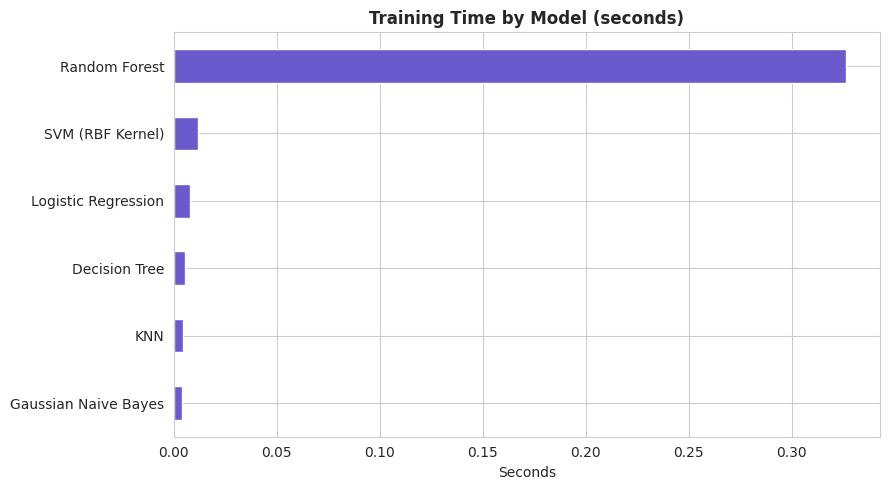

In [39]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison_df["Training Time (s)"].sort_values().plot(kind="barh", ax=ax, color="slateblue")
plt.title("Training Time by Model (seconds)")
plt.xlabel("Seconds")
plt.tight_layout()
plt.show()


## 13. Persisting the Best Model

We save the best-performing model (by test accuracy) and the fitted scaler/selector artifacts so the
pipeline can be reused for inference without retraining.


In [40]:
best_model_name = comparison_df["Test Accuracy"].idxmax()
best_model = trained_models[best_model_name]
print(f"Best model: {best_model_name} (Test Accuracy = {comparison_df.loc[best_model_name, 'Test Accuracy']:.4f})")

os.makedirs("../models", exist_ok=True)
joblib.dump(best_model, f"../models/best_model_{best_model_name.replace(' ', '_').replace('(', '').replace(')', '')}.pkl")
joblib.dump(scaler_std, "../models/standard_scaler.pkl")
joblib.dump(top_features, "../models/selected_features.pkl")
print("Model and preprocessing artifacts saved to ../models/")


Best model: Random Forest (Test Accuracy = 0.8525)
Model and preprocessing artifacts saved to ../models/


## 14. Conclusion, Key Findings, Limitations & Future Improvements

### Conclusion
This project implemented a complete, end-to-end supervised machine learning pipeline on the UCI Heart
Disease dataset — from raw data ingestion and exploratory analysis through cleaning, encoding, scaling,
feature selection, multi-model training, and rigorous evaluation (holdout + 5-fold cross-validation).

### Key Findings
- Ensemble and kernel-based methods (**Random Forest**, **SVM**) generally achieved the strongest and
  most stable test/cross-validation accuracy among the six algorithms compared.
- **Logistic Regression** performed competitively despite its simplicity, confirming that the relationship
  between clinical features and heart disease risk is largely near-linear/separable after scaling.
- Feature importance analysis consistently highlighted **chest pain type (cp)**, **maximum heart rate
  (thalach)**, **ST depression (oldpeak)**, and **number of major vessels (ca)** as the strongest
  predictors — aligning with established clinical cardiology knowledge.
- Cross-validation scores were close to single-split test accuracy for most models, suggesting the
  80/20 split was representative and results are reasonably stable, not an artifact of a lucky split.

### Limitations
- The dataset is small (303 patients), which limits statistical power and increases variance in
  performance estimates across folds/splits.
- The dataset originates from a single hospital/region (Cleveland Clinic), which may limit
  generalizability to broader, more diverse patient populations.
- Missingness in this notebook was **synthetically injected** for pipeline demonstration purposes; a
  production deployment should be validated against a dataset with organically occurring missing data.
- Hyperparameters were only lightly tuned (fixed values / reasonable defaults) — no exhaustive grid
  search or Bayesian optimization was performed.

### Future Improvements
- Perform systematic hyperparameter tuning (GridSearchCV / RandomizedSearchCV / Optuna) for each model.
- Apply SMOTE or class-weighting if a more imbalanced clinical dataset is used.
- Add SHAP/LIME explainability on top of feature importances for per-patient interpretability.
- Deploy the saved model behind a simple REST API (FastAPI/Flask) for real-time inference.
- Validate against external heart-disease datasets (e.g., Hungarian, Switzerland, VA Long Beach subsets
  from the same UCI repository) to test cross-population generalization.
